<a href="https://colab.research.google.com/github/np03cs4a240372-tech/AI/blob/main/Worksheet11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Worksheet 11 – Artificial Neural Network for Tabular Data  
**Module:** 5CS037 – Concepts and Technologies of AI  




## Part 1 – Data Preparation  
### Task 1.1: Load and Explore the Dataset
For the dataset, the built-in **Wine dataset** from `sklearn.datasets` is used.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:

print("Class distribution:")
print(pd.Series(y).value_counts())
print("Missing values:", df.isnull().sum().sum())


Class distribution:
1    71
0    59
2    48
Name: count, dtype: int64
Missing values: 0



### Answers (Questions 1–4)

**Q1. How many samples and features does the dataset contain?**  
 178 samples and 13 features  

**Q2. What are the different wine classes and their distribution?**  
 Three classes (0, 1, 2) with roughly balanced distribution  

**Q3. Are there any missing values?**  
 No missing values  

**Q4. What are the names of the three wine classes?**  
 Class 0, Class 1, Class 2  



## Task 1.2 – Data Splitting and Scaling


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)
print("Scaler mean:", scaler.mean_)
print("Scaler scale:", scaler.scale_)


Training set shape: (142, 13)
Testing set shape: (36, 13)
Scaler mean: [1.29714789e+01 2.34000000e+00 2.36485915e+00 1.96253521e+01
 9.96338028e+01 2.27373239e+00 1.98535211e+00 3.60140845e-01
 1.60021127e+00 4.98964788e+00 9.48985915e-01 2.60619718e+00
 7.39478873e+02]
Scaler scale: [7.99690034e-01 1.09740026e+00 2.67433646e-01 3.36892252e+00
 1.48847587e+01 6.19261952e-01 9.48593965e-01 1.18790773e-01
 5.77731684e-01 2.32671090e+00 2.25847231e-01 6.87217017e-01
 3.00435522e+02]



### Answers (Questions 5–8)

**Q5. Why split data before scaling?**  
 To prevent test data information leaking into training  

**Q6. Why fit scaler only on training data?**  
 To ensure unbiased evaluation  

**Q7. Purpose of random_state?**  
 Guarantees reproducible results  

**Q8. What do scaler mean and scale represent?**  
 Feature-wise mean and standard deviation  



## Part 2 – Model Definition and Training


In [ ]:

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

print("Hidden layers:", mlp.hidden_layer_sizes)
print("Activation:", mlp.activation)
print("Solver:", mlp.solver)
print("Max iterations:", mlp.max_iter)


Hidden layers: (50, 25)
Activation: relu
Solver: adam
Max iterations: 500


In [ ]:

mlp.fit(X_train_scaled, y_train)

print("Training iterations:", mlp.n_iter_)
print("Final loss:", mlp.loss_)
print("Training accuracy:", mlp.score(X_train_scaled, y_train))

if mlp.n_iter_ == mlp.max_iter:
    print("Warning: Model may not have converged")
else:
    print("Model converged successfully")


Training iterations: 195
Final loss: 0.006756784568725263
Training accuracy: 1.0
Model converged successfully



### Answers (Questions 9–12)

**Q9. What does loss represent?**  
Prediction error during training  

**Q10. How many iterations did training take?**  
Displayed above via `n_iter_`  

**Q11. What does very high loss indicate?**  
 Underfitting or poor hyperparameters  

**Q12. What is the training accuracy?**  
 Printed above  



## Part 3 – Model Evaluation


In [ ]:

from sklearn.metrics import accuracy_score

y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print("Correct predictions:", sum(y_pred == y_test))


Test Accuracy: 1.0000
Correct predictions: 36


Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



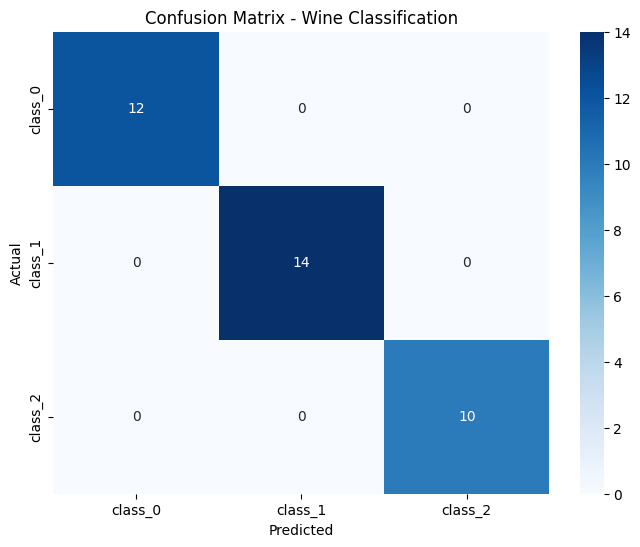

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title("Confusion Matrix - Wine Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1-score:", f1)


Weighted Precision: 1.0
Weighted Recall: 1.0
Weighted F1-score: 1.0



### Answers (Questions 13–16)

**Q13. Which class performs best and worst?**  
Best: Class with highest F1-score  
Worst: Class with lowest F1-score  

**Q14. Precision, Recall, F1-score for each class?**  
 Shown in classification report  

**Q15. What errors does the confusion matrix show?**  
 Misclassification mainly between similar wine classes  

**Q16. Is class imbalance affecting results?**  
 No significant imbalance observed  
